# Baseline Model 1: Standard ResNet-18

In [20]:
# Imports
import os
import json
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


In [21]:
## Dataset Structure and Label Format

# Verify the train/validation/test split,
# count images and annotation files, and 
# inspect a sample YOLO label file to confirm the annotation format and
# class index mapping used in the dataset

base = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT"

for split in ["train", "val", "test"]:
    img_dir = Path(base) / split / "images"
    lbl_dir = Path(base) / split / "labels"
    imgs = list(img_dir.glob("*.jpg")) if img_dir.exists() else []
    lbls = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []
    print(f"{split:5s} → images: {len(imgs):5d}  labels: {len(lbls):5d}")

# Show what a label file looks like
sample_lbl = list((Path(base) / "train" / "labels").glob("*.txt"))[1]
print(f"\nSample label file: {sample_lbl.name}")

with open(sample_lbl) as f:
    for line in f:
        print(f"  {line.strip()}")
        
print("\nFormat: class_id  cx  cy  width  height  (all normalized 0-1)")
print("Classes used: 0=D00 Longitudinal  1=D10 Transverse  2=D20 Alligator  3=D40 Pothole")
print("Dropped class: original 3 = Other Corruption")

train → images: 26869  labels: 26869
val   → images:  5758  labels:  5758
test  → images:  5758  labels:  5758

Sample label file: Norway_007787.txt
  4 0.817127 0.709031 0.021159 0.020988
  4 0.704079 0.637361 0.054647 0.026727
  4 0.769168 0.777882 0.023038 0.020988
  4 0.600114 0.665908 0.014512 0.013361
  4 0.672612 0.706935 0.019592 0.013410
  4 0.747222 0.747167 0.026449 0.012241
  4 0.735597 0.654572 0.087753 0.037657
  4 0.645348 0.701103 0.012734 0.018077

Format: class_id  cx  cy  width  height  (all normalized 0-1)
Classes used: 0=D00 Longitudinal  1=D10 Transverse  2=D20 Alligator  3=D40 Pothole
Dropped class: original 3 = Other Corruption


In [22]:
CONFIG = {
    "base_dir":    "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT",
    "output_dir":  "/kaggle/working/baseline_resnet18",

    "class_names": [
    "Longitudinal Crack (D00)",   # 0
    "Transverse Crack (D10)",     # 1
    "Alligator Crack (D20)",      # 2
    "Pothole (D40)",              # 3
    ],
    "num_classes": 4,

    "img_size":     224,
    "batch_size":   32,
    "num_epochs":   25,
    "lr":           1e-4,
    "weight_decay": 1e-4,
    "patience":     6,
    "num_workers":  2,

    "pretrained":  True,
    "dropout":     0.5,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print("Config ready. Output dir:", CONFIG["output_dir"])

Config ready. Output dir: /kaggle/working/baseline_resnet18


In [6]:
def parse_yolo_label(txt_path: Path, num_classes: int = 4) -> int:
    """
    Convert YOLO annotations to one image label.

    Keep classes:
      0->0  D00
      1->1  D10
      2->2  D20
      4->3  D40

    Drop:
      3 = Other Corruption

    Rule:
    1. Majority vote by count
    2. Tie break by total bbox area
    """
    if not txt_path.exists():
        return -1

    remap = {0: 0, 1: 1, 2: 2, 4: 3}

    try:
        class_counts = Counter()
        class_areas = Counter()

        with open(txt_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                old_id = int(parts[0])

                if old_id not in remap:
                    continue

                new_id = remap[old_id]

                _, cx, cy, w, h = map(float, parts)
                area = w * h

                class_counts[new_id] += 1
                class_areas[new_id] += area

        if not class_counts:
            return -1

        max_count = max(class_counts.values())
        tied = [c for c, n in class_counts.items() if n == max_count]

        if len(tied) == 1:
            return tied[0]

        return max(tied, key=lambda c: class_areas[c])

    except (ValueError, IOError):
        return -1
# Quick test
sample_lbl = list((Path(CONFIG["base_dir"]) / "train" / "labels").glob("*.txt"))[1]
result = parse_yolo_label(sample_lbl, CONFIG["num_classes"])
if result != -1:
    print(f"Test parse on {sample_lbl.name} → class index: {result} "
          f"({CONFIG['class_names'][result]})")
else:
    print(f"Test parse on {sample_lbl.name} → invalid label")

Test parse on Norway_007787.txt → class index: 3 (Pothole (D40))


Since some images contain multiple damage types, this function converts object-level YOLO annotations into a single image-level class label using **majority vote**. The most frequent damage class in the annotation file is selected as the ground truth label for classification.

In [23]:
class RDD2022Dataset(Dataset):
    """
    Image-level classification dataset for RDD2022.
    
    Reads YOLO .txt annotations and assigns each image a single
    class label = most frequent damage type in that image.
    """

    def __init__(self, split: str, config: dict, transform=None):
        self.config    = config
        self.transform = transform

        base    = Path(config["base_dir"])
        img_dir = base / split / "images"
        lbl_dir = base / split / "labels"

        all_imgs = sorted(img_dir.glob("*.jpg"))

        self.img_paths = []
        self.labels    = []
        skipped        = 0

        for img_path in all_imgs:
            txt_path = lbl_dir / (img_path.stem + ".txt")
            label    = parse_yolo_label(txt_path, config["num_classes"])
            if label == -1:
                skipped += 1
                continue
            self.img_paths.append(img_path)
            self.labels.append(label)

        self.label_counts = Counter(self.labels)
        total = len(self.img_paths)

        print(f"\n[{split.upper()}] {total} images  (skipped {skipped})")
        for i, name in enumerate(config["class_names"]):
            count = self.label_counts.get(i, 0)
            pct   = 100 * count / total if total > 0 else 0
            bar   = "█" * int(pct / 2)
            print(f"  {name:35s}: {count:5d} ({pct:5.1f}%)  {bar}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img   = Image.open(self.img_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label, self.img_paths[idx].name

In [24]:
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]
SZ       = CONFIG["img_size"]

train_tf = transforms.Compose([
    transforms.Resize((SZ + 32, SZ + 32)),
    transforms.RandomCrop(SZ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

val_test_tf = transforms.Compose([
    transforms.Resize((SZ, SZ)),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

# Build datasets
train_ds = RDD2022Dataset("train", CONFIG, transform=train_tf)
val_ds   = RDD2022Dataset("val",   CONFIG, transform=val_test_tf)
test_ds  = RDD2022Dataset("test",  CONFIG, transform=val_test_tf)

# Build loaders
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=CONFIG["num_workers"],
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"],
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"],
                          pin_memory=True)

print(f"\nLoaders ready.")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")


[TRAIN] 16731 images  (skipped 10138)
  Longitudinal Crack (D00)           :  7472 ( 44.7%)  ██████████████████████
  Transverse Crack (D10)             :  3037 ( 18.2%)  █████████
  Alligator Crack (D20)              :  4613 ( 27.6%)  █████████████
  Pothole (D40)                      :  1609 (  9.6%)  ████

[VAL] 3493 images  (skipped 2265)
  Longitudinal Crack (D00)           :  1598 ( 45.7%)  ██████████████████████
  Transverse Crack (D10)             :   630 ( 18.0%)  █████████
  Alligator Crack (D20)              :   936 ( 26.8%)  █████████████
  Pothole (D40)                      :   329 (  9.4%)  ████

[TEST] 3543 images  (skipped 2215)
  Longitudinal Crack (D00)           :  1682 ( 47.5%)  ███████████████████████
  Transverse Crack (D10)             :   601 ( 17.0%)  ████████
  Alligator Crack (D20)              :   932 ( 26.3%)  █████████████
  Pothole (D40)                      :   328 (  9.3%)  ████

Loaders ready.
  Train batches : 523
  Val batches   : 110
  Test batches

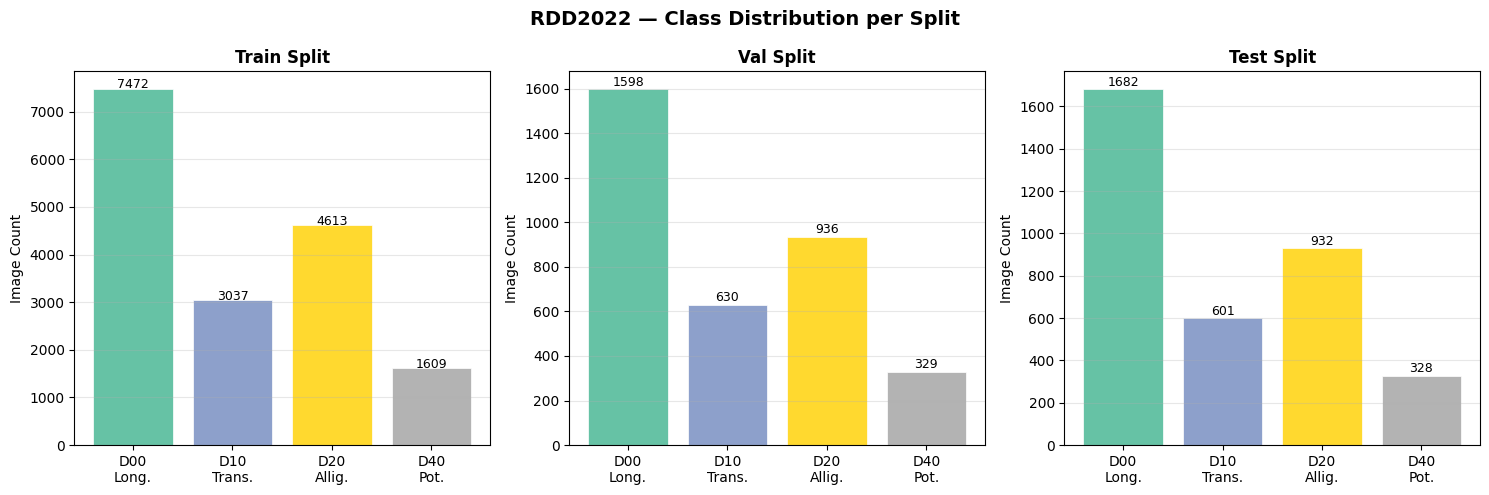

Note: D00 (longitudinal cracks) dominates — class weighting will handle this.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
short = ["D00\nLong.", "D10\nTrans.", "D20\nAllig.", "D40\nPot."]
colors = plt.cm.Set2(np.linspace(0, 1, 4))

for ax, (ds, split) in zip(axes, [(train_ds, "Train"),
                                   (val_ds,   "Val"),
                                   (test_ds,  "Test")]):
    counts = [ds.label_counts.get(i, 0) for i in range(CONFIG["num_classes"])]
    bars   = ax.bar(short, counts, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{split} Split", fontsize=12, fontweight="bold")
    ax.set_ylabel("Image Count")
    ax.grid(axis="y", alpha=0.3)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 15,
                str(c), ha="center", fontsize=9)

plt.suptitle("RDD2022 — Class Distribution per Split",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/class_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Note: D00 (longitudinal cracks) dominates — class weighting will handle this.")

To address class imbalance, inverse-frequency class weights are computed from the training set and used during loss calculation. A pretrained ResNet-18 is then adapted for the road damage classification task by replacing its final layer with a dropout layer followed by a new classifier matching the number of target classes.

In [8]:
# Class weights — inverse frequency to handle imbalance
counts  = np.array([train_ds.label_counts.get(i, 1)
                    for i in range(CONFIG["num_classes"])], dtype=np.float32)
weights = 1.0 / counts
weights = weights / weights.sum() * CONFIG["num_classes"]
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

print("Class weights (higher = rarer class, gets more attention):")
for name, w in zip(CONFIG["class_names"], weights):
    print(f"  {name:35s}: {w:.4f}")

# Build ResNet-18
weights_pretrained = ResNet18_Weights.IMAGENET1K_V1 if CONFIG["pretrained"] else None
model = models.resnet18(weights=weights_pretrained)

# Replace final FC: 512 → Dropout → 4 classes
in_features = model.fc.in_features  # 512
model.fc = nn.Sequential(
    nn.Dropout(p=CONFIG["dropout"]),
    nn.Linear(in_features, CONFIG["num_classes"])
)
model = model.to(DEVICE)

# Report
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
size_mb  = sum(p.numel() * p.element_size()
               for p in model.parameters()) / 1024**2
print(f"\nModel: ResNet-18")
print(f"  Trainable params : {n_params:,}")
print(f"  Model size       : {size_mb:.1f} MB")
print(f"  Output classes   : {CONFIG['num_classes']}")

Class weights (higher = rarer class, gets more attention):
  Longitudinal Crack (D00)           : 0.4114
  Transverse Crack (D10)             : 1.0121
  Alligator Crack (D20)              : 0.6663
  Pothole (D40)                      : 1.9103
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]



Model: ResNet-18
  Trainable params : 11,178,564
  Model size       : 42.6 MB
  Output classes   : 4


In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(),
                       lr=CONFIG["lr"],
                       weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["num_epochs"], eta_min=1e-6
)

print("Training setup:")
print(f"  Loss      : CrossEntropyLoss (weighted)")
print(f"  Optimizer : Adam  lr={CONFIG['lr']}  wd={CONFIG['weight_decay']}")
print(f"  Scheduler : CosineAnnealingLR  T_max={CONFIG['num_epochs']}")
print(f"  Epochs    : {CONFIG['num_epochs']}  (early stop patience={CONFIG['patience']})")

Training setup:
  Loss      : CrossEntropyLoss (weighted)
  Optimizer : Adam  lr=0.0001  wd=0.0001
  Scheduler : CosineAnnealingLR  T_max=25
  Epochs    : 25  (early stop patience=6)


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, epoch, total_epochs):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for i, (imgs, labels, _) in enumerate(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)

        if (i + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}/{total_epochs} "
                  f"[{i+1}/{len(loader)}]  "
                  f"loss={loss.item():.4f}  "
                  f"acc={100.*correct/total:.1f}%")

    return total_loss / total, 100. * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss        = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)

            total_loss  += loss.item() * imgs.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds) * 100
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, acc, f1_macro, all_preds, all_labels

print("Training functions defined.")

Training functions defined.


In [11]:
history = {k: [] for k in
           ["train_loss", "train_acc", "val_loss", "val_acc", "val_f1"]}

best_f1, best_epoch, patience_ctr = 0.0, 0, 0
t0 = time.time()

print("="*60)
print("Starting training...")
print("="*60)

for epoch in range(CONFIG["num_epochs"]):
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"\n── Epoch {epoch+1}/{CONFIG['num_epochs']}  lr={lr_now:.2e} ──")

    tr_loss, tr_acc           = train_one_epoch(model, train_loader,
                                                criterion, optimizer,
                                                epoch, CONFIG["num_epochs"])
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)

    print(f"  Train  loss={tr_loss:.4f}  acc={tr_acc:.2f}%")
    print(f"  Val    loss={vl_loss:.4f}  acc={vl_acc:.2f}%  F1={vl_f1:.4f}")

    if vl_f1 > best_f1:
        best_f1, best_epoch, patience_ctr = vl_f1, epoch + 1, 0
        ckpt_path = f"{CONFIG['output_dir']}/best_resnet18.pth"
        torch.save({
            "epoch":       epoch + 1,
            "model_state": model.state_dict(),
            "val_f1":      best_f1,
            "val_acc":     vl_acc,
        }, ckpt_path)
        print(f"  ✓ Best model saved  (F1={best_f1:.4f})")
    else:
        patience_ctr += 1
        print(f"  No improvement. Patience {patience_ctr}/{CONFIG['patience']}")
        if patience_ctr >= CONFIG["patience"]:
            print(f"\nEarly stopping — best was epoch {best_epoch}")
            break

elapsed = time.time() - t0
print(f"\nTraining finished in {elapsed/60:.1f} min")
print(f"Best val F1 = {best_f1:.4f} at epoch {best_epoch}")

Starting training...

── Epoch 1/25  lr=1.00e-04 ──
  Epoch 1/25 [100/523]  loss=1.4327  acc=38.5%
  Epoch 1/25 [200/523]  loss=0.9317  acc=43.1%
  Epoch 1/25 [300/523]  loss=1.0071  acc=45.6%
  Epoch 1/25 [400/523]  loss=1.1181  acc=47.3%
  Epoch 1/25 [500/523]  loss=0.9364  acc=48.6%
  Train  loss=1.1505  acc=48.98%
  Val    loss=0.9616  acc=62.01%  F1=0.5863
  ✓ Best model saved  (F1=0.5863)

── Epoch 2/25  lr=9.96e-05 ──
  Epoch 2/25 [100/523]  loss=1.2603  acc=57.8%
  Epoch 2/25 [200/523]  loss=0.7515  acc=57.4%
  Epoch 2/25 [300/523]  loss=1.1159  acc=57.4%
  Epoch 2/25 [400/523]  loss=0.9422  acc=57.6%
  Epoch 2/25 [500/523]  loss=0.8770  acc=57.4%
  Train  loss=0.9621  acc=57.57%
  Val    loss=0.8715  acc=64.76%  F1=0.6133
  ✓ Best model saved  (F1=0.6133)

── Epoch 3/25  lr=9.84e-05 ──
  Epoch 3/25 [100/523]  loss=0.5804  acc=61.5%
  Epoch 3/25 [200/523]  loss=0.9350  acc=60.8%
  Epoch 3/25 [300/523]  loss=0.9497  acc=61.1%
  Epoch 3/25 [400/523]  loss=1.0634  acc=61.4%
  Epoc

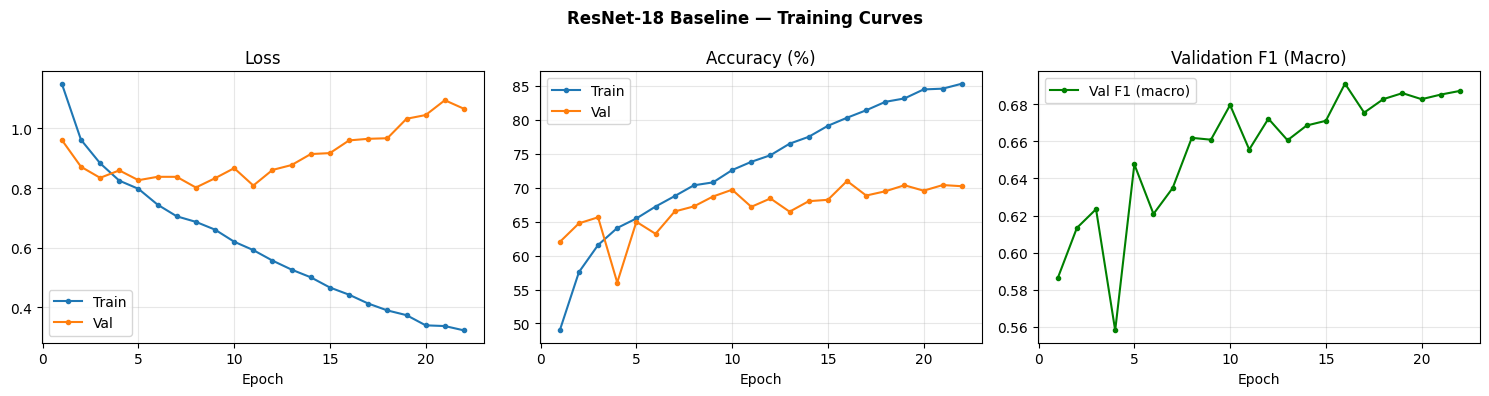

In [12]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history["train_loss"], label="Train", marker="o", ms=3)
axes[0].plot(epochs, history["val_loss"],   label="Val",   marker="o", ms=3)
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_xlabel("Epoch")

axes[1].plot(epochs, history["train_acc"], label="Train", marker="o", ms=3)
axes[1].plot(epochs, history["val_acc"],   label="Val",   marker="o", ms=3)
axes[1].set_title("Accuracy (%)"); axes[1].legend(); axes[1].grid(alpha=.3)
axes[1].set_xlabel("Epoch")

axes[2].plot(epochs, history["val_f1"], color="green",
             label="Val F1 (macro)", marker="o", ms=3)
axes[2].set_title("Validation F1 (Macro)"); axes[2].legend(); axes[2].grid(alpha=.3)
axes[2].set_xlabel("Epoch")

plt.suptitle("ResNet-18 Baseline — Training Curves", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/training_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Load best checkpoint
ckpt = torch.load(f"{CONFIG['output_dir']}/best_resnet18.pth",
                  map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded epoch {ckpt['epoch']}  (val F1={ckpt['val_f1']:.4f})\n")

# Run on test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels, _ in test_loader:
        out = model(imgs.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

# Metrics
acc    = accuracy_score(all_labels, all_preds) * 100
f1_mac = f1_score(all_labels, all_preds, average="macro",    zero_division=0)
f1_wt  = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
prec   = precision_score(all_labels, all_preds, average="macro", zero_division=0)
rec    = recall_score(all_labels, all_preds,    average="macro", zero_division=0)

print("="*45)
print(f"  Accuracy          : {acc:.2f}%")
print(f"  F1 (macro)        : {f1_mac:.4f}")
print(f"  F1 (weighted)     : {f1_wt:.4f}")
print(f"  Precision (macro) : {prec:.4f}")
print(f"  Recall (macro)    : {rec:.4f}")
print("="*45)

print("\nPer-class breakdown:")
print(classification_report(all_labels, all_preds,
                             target_names=CONFIG["class_names"],
                             zero_division=0))

# Save metrics for later comparison against CBM
metrics = {
    "model":           "ResNet-18 Baseline (Black Box)",
    "accuracy":        round(acc, 4),
    "f1_macro":        round(f1_mac, 4),
    "f1_weighted":     round(f1_wt, 4),
    "precision_macro": round(prec, 4),
    "recall_macro":    round(rec, 4),
}
with open(f"{CONFIG['output_dir']}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(f"\nMetrics saved → {CONFIG['output_dir']}/metrics.json")

Loaded epoch 16  (val F1=0.6910)

  Accuracy          : 71.94%
  F1 (macro)        : 0.6902
  F1 (weighted)     : 0.7230
  Precision (macro) : 0.6897
  Recall (macro)    : 0.6982

Per-class breakdown:
                          precision    recall  f1-score   support

Longitudinal Crack (D00)       0.80      0.77      0.78      1682
  Transverse Crack (D10)       0.53      0.69      0.60       601
   Alligator Crack (D20)       0.78      0.66      0.72       932
           Pothole (D40)       0.66      0.67      0.66       328

                accuracy                           0.72      3543
               macro avg       0.69      0.70      0.69      3543
            weighted avg       0.73      0.72      0.72      3543


Metrics saved → /kaggle/working/baseline_resnet18/metrics.json


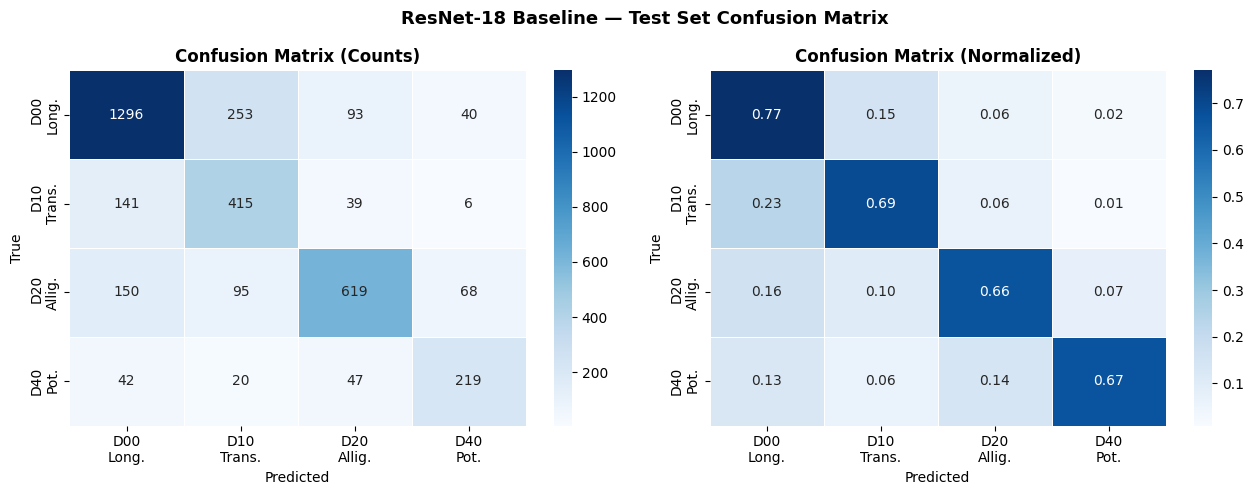

In [14]:
cm   = confusion_matrix(all_labels, all_preds)
cmn  = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
tags = ["D00\nLong.", "D10\nTrans.", "D20\nAllig.", "D40\nPot."]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, fmt, title in zip(
    axes, [cm, cmn], ["d", ".2f"], ["Counts", "Normalized"]
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=tags, yticklabels=tags, ax=ax,
                linewidths=0.5, linecolor="white")
    ax.set_title(f"Confusion Matrix ({title})", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("ResNet-18 Baseline — Test Set Confusion Matrix",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/confusion_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Measure inference speed — needed for your efficiency results table
model.eval()
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

# Warmup passes
with torch.no_grad():
    for _ in range(20):
        _ = model(dummy)

# Timed passes
t0 = time.time()
with torch.no_grad():
    for _ in range(200):
        _ = model(dummy)
ms_per_img = (time.time() - t0) / 200 * 1000

n_params = sum(p.numel() for p in model.parameters())
size_mb  = sum(p.numel() * p.element_size()
               for p in model.parameters()) / 1024**2

print("="*45)
print("  Model Size Report — for Results Table")
print("="*45)
print(f"  Parameters      : {n_params:,}")
print(f"  Model size      : {size_mb:.1f} MB")
print(f"  Inference time  : {ms_per_img:.2f} ms/image  ({DEVICE})")
print("="*45)

  Model Size Report — for Results Table
  Parameters      : 11,178,564
  Model size      : 42.6 MB
  Inference time  : 2.67 ms/image  (cuda)


# Baseline 2: ResNet-18 + Post-hoc Grad-CAM

In [9]:
!pip install grad-cam -q

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 91.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [8]:
ckpt_path = "/kaggle/input/models/ammaraharoonn/best-resnet18/other/default/1/best_resnet18 (1).pth"

model = models.resnet18(weights=None)

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=CONFIG["dropout"]),
    nn.Linear(in_features, CONFIG["num_classes"])
)

checkpoint = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])

model = model.to(DEVICE)
model.eval()

print("Checkpoint loaded successfully")
print("Best epoch :", checkpoint["epoch"])
print("Best val F1:", checkpoint["val_f1"])

Checkpoint loaded successfully
Best epoch : 25
Best val F1: 0.6961117245521382


In [10]:
cam_tf = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


In [31]:
target_layers = [model.layer4[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

In [32]:
def run_gradcam(img_path, true_label=None):
    img_pil = Image.open(img_path).convert("RGB")

    # raw image for visualization
    rgb_img = np.array(
        img_pil.resize((CONFIG["img_size"], CONFIG["img_size"]))
    ).astype(np.float32) / 255.0

    # model input
    input_tensor = cam_tf(img_pil).unsqueeze(0).to(DEVICE)

    # prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        pred_idx = outputs.argmax(1).item()
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    # CAM for predicted class
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    pred_name = CONFIG["class_names"][pred_idx]
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(rgb_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(grayscale_cam, cmap="jet")
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM\nPred: {pred_name}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Print scores
    print("Prediction probabilities:")
    for i, p in enumerate(probs):
        print(f"  {CONFIG['class_names'][i]:30s}: {p:.4f}")

    if true_label is not None:
        print("True Label:", CONFIG["class_names"][true_label])

Sample 1/5
File: Japan_007453.jpg


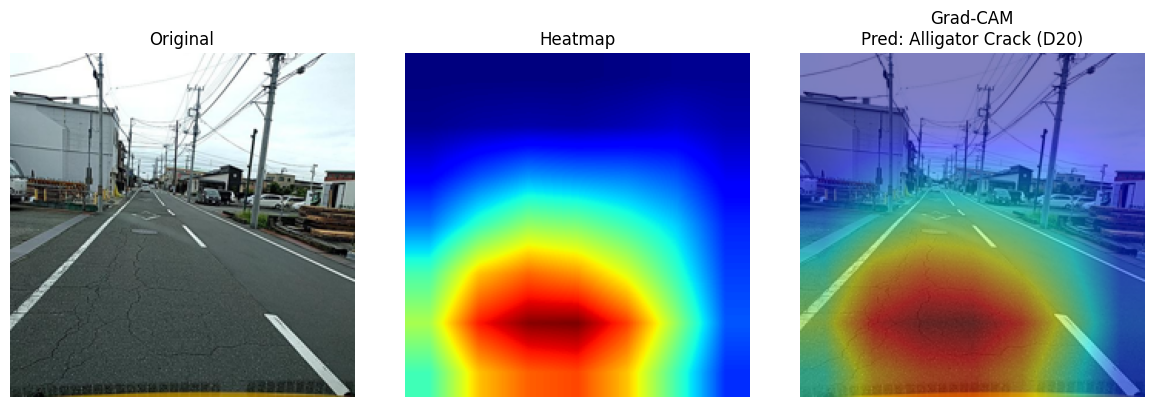

Prediction probabilities:
  Longitudinal Crack (D00)      : 0.0018
  Transverse Crack (D10)        : 0.0870
  Alligator Crack (D20)         : 0.9112
  Pothole (D40)                 : 0.0000
True Label: Alligator Crack (D20)
Sample 2/5
File: India_000485.jpg


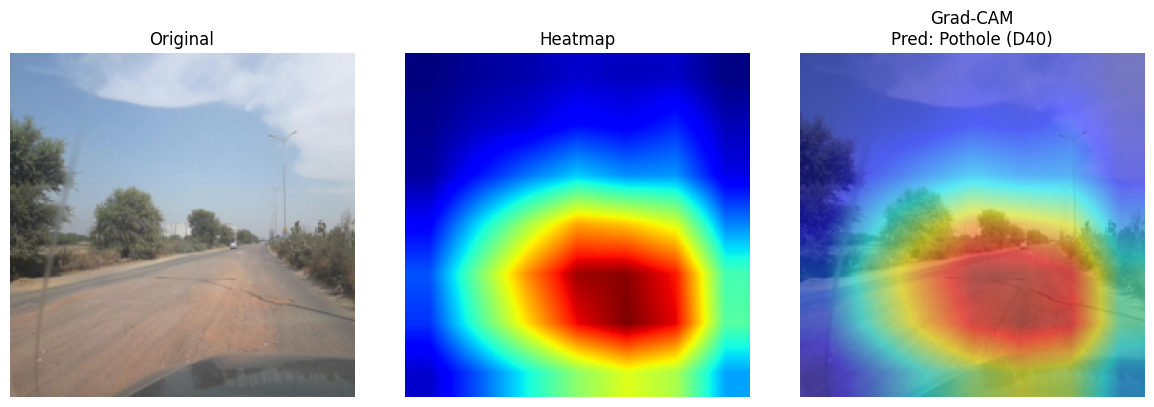

Prediction probabilities:
  Longitudinal Crack (D00)      : 0.0005
  Transverse Crack (D10)        : 0.0000
  Alligator Crack (D20)         : 0.0001
  Pothole (D40)                 : 0.9994
True Label: Pothole (D40)
Sample 3/5
File: Norway_002000.jpg


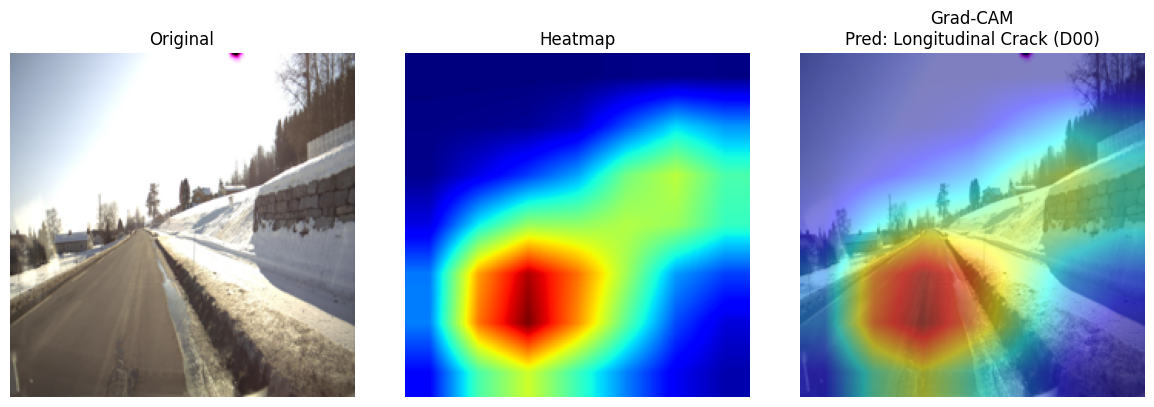

Prediction probabilities:
  Longitudinal Crack (D00)      : 0.9632
  Transverse Crack (D10)        : 0.0233
  Alligator Crack (D20)         : 0.0135
  Pothole (D40)                 : 0.0000
True Label: Longitudinal Crack (D00)
Sample 4/5
File: Japan_002317.jpg


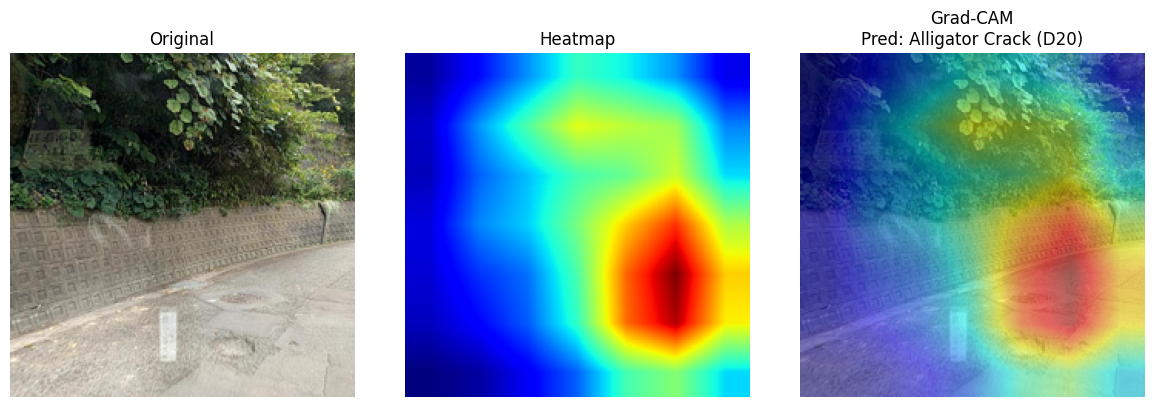

Prediction probabilities:
  Longitudinal Crack (D00)      : 0.0035
  Transverse Crack (D10)        : 0.0000
  Alligator Crack (D20)         : 0.9882
  Pothole (D40)                 : 0.0082
True Label: Pothole (D40)
Sample 5/5
File: Japan_010884.jpg


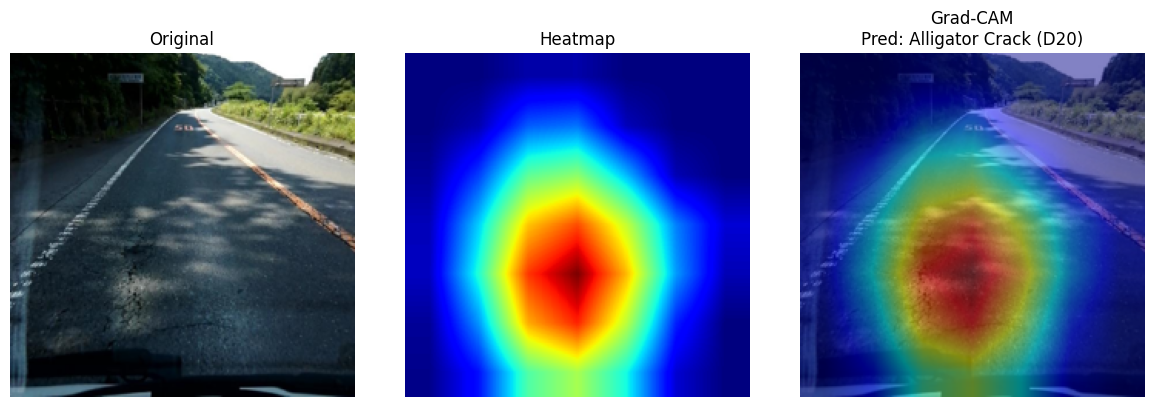

Prediction probabilities:
  Longitudinal Crack (D00)      : 0.0468
  Transverse Crack (D10)        : 0.3667
  Alligator Crack (D20)         : 0.5865
  Pothole (D40)                 : 0.0000
True Label: Alligator Crack (D20)


In [33]:
num_samples = 5
indices = np.random.choice(len(test_ds), size=num_samples, replace=False)

for n, idx in enumerate(indices, 1):
    img_tensor, label, fname = test_ds[idx]
    img_path = test_ds.img_paths[idx]

    print("=" * 70)
    print(f"Sample {n}/{num_samples}")
    print("File:", fname)

    run_gradcam(img_path, true_label=label)